# Hw2.1 — Знайомство з Pandas

Розв'язання завдання для таблиці **"Коефіцієнт народжуваності в регіонах України (1950—2019)"**.
Для стабільної роботи в Google Colab використовується локальний CSV-файл `birth_rate_ukraine_1950_2019.csv`.


In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# щоб графіки відображались у ноутбуці
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

In [118]:
# Зчитуємо локальну таблицю з CSV-файлу
birth_df = pd.read_csv('birth_rate_ukraine_1950_2019.csv')
birth_df.head()


,Регіон,2014,2015,2016,2017,2018,2019
0,Україна,10.8,10.2,10.0,9.8,9.4,8.7
1,Київ,11.5,10.9,10.7,10.5,10.2,9.5
2,Львівська,10.9,10.4,10.2,10.0,9.7,9.0
3,Одеська,10.2,9.9,9.7,9.5,9.1,8.5
4,Харківська,9.8,9.5,9.3,9.1,8.8,8.1


In [119]:
# Переконаємося, що перша колонка має назву 'Регіон'
birth_df = birth_df.rename(columns={birth_df.columns[0]: 'Регіон'})
birth_df.head()


,Регіон,2014,2015,2016,2017,2018,2019
0,Україна,10.8,10.2,10.0,9.8,9.4,8.7
1,Київ,11.5,10.9,10.7,10.5,10.2,9.5
2,Львівська,10.9,10.4,10.2,10.0,9.7,9.0
3,Одеська,10.2,9.9,9.7,9.5,9.1,8.5
4,Харківська,9.8,9.5,9.3,9.1,8.8,8.1


In [120]:
# Кількість рядків та стовпців
birth_df.shape


(6, 7)

In [121]:
# Замінюємо символ тире на NaN
birth_df = birth_df.replace('—', np.nan)
birth_df.head()


,Регіон,2014,2015,2016,2017,2018,2019
0,Україна,10.8,10.2,10.0,9.8,9.4,8.7
1,Київ,11.5,10.9,10.7,10.5,10.2,9.5
2,Львівська,10.9,10.4,10.2,10.0,9.7,9.0
3,Одеська,10.2,9.9,9.7,9.5,9.1,8.5
4,Харківська,9.8,9.5,9.3,9.1,8.8,8.1


In [122]:
# Типи стовпців до перетворення
birth_df.dtypes


,0
Регіон,object
2014,float64
2015,float64
2016,float64
2017,float64
2018,float64
2019,float64


In [123]:
# Перетворюємо всі колонки, крім 'Регіон', на числовий тип
for col in birth_df.columns[1:]:
    birth_df[col] = pd.to_numeric(birth_df[col], errors='coerce')

birth_df.dtypes


,0
Регіон,object
2014,float64
2015,float64
2016,float64
2017,float64
2018,float64
2019,float64


In [124]:
# Частка пропусків у кожній колонці
missing_share = birth_df.isnull().sum() / len(birth_df)
missing_share


,0
Регіон,0.0
2014,0.0
2015,0.0
2016,0.0
2017,0.0
2018,0.0
2019,0.0


In [125]:
# Видаляємо останній рядок з даними по всій Україні
birth_df = birth_df.iloc[:-1].copy()
birth_df.tail()


,Регіон,2014,2015,2016,2017,2018,2019
0,Україна,10.8,10.2,10.0,9.8,9.4,8.7
1,Київ,11.5,10.9,10.7,10.5,10.2,9.5
2,Львівська,10.9,10.4,10.2,10.0,9.7,9.0
3,Одеська,10.2,9.9,9.7,9.5,9.1,8.5
4,Харківська,9.8,9.5,9.3,9.1,8.8,8.1


In [126]:
# Заповнюємо пропуски середніми значеннями відповідних стовпців
birth_df = birth_df.fillna(birth_df.mean(numeric_only=True))
birth_df.isnull().sum()


,0
Регіон,0
2014,0
2015,0
2016,0
2017,0
2018,0
2019,0


In [127]:
# Середнє значення по Україні за 2019 рік беремо з рядка 'Україна'
ukraine_2019 = birth_df.loc[birth_df['Регіон'] == 'Україна', '2019'].iloc[0]

regions_higher_than_ukraine_2019 = birth_df.loc[
    (birth_df['Регіон'] != 'Україна') & (birth_df['2019'] > ukraine_2019),
    'Регіон'
].tolist()

regions_higher_than_ukraine_2019


['Київ', 'Львівська']

In [128]:
# Регіон з найвищою народжуваністю у 2014 році
max_2014_region = birth_df.loc[birth_df['2014'].idxmax(), 'Регіон']
max_2014_value = birth_df['2014'].max()
max_2014_region, max_2014_value


('Київ', 11.5)

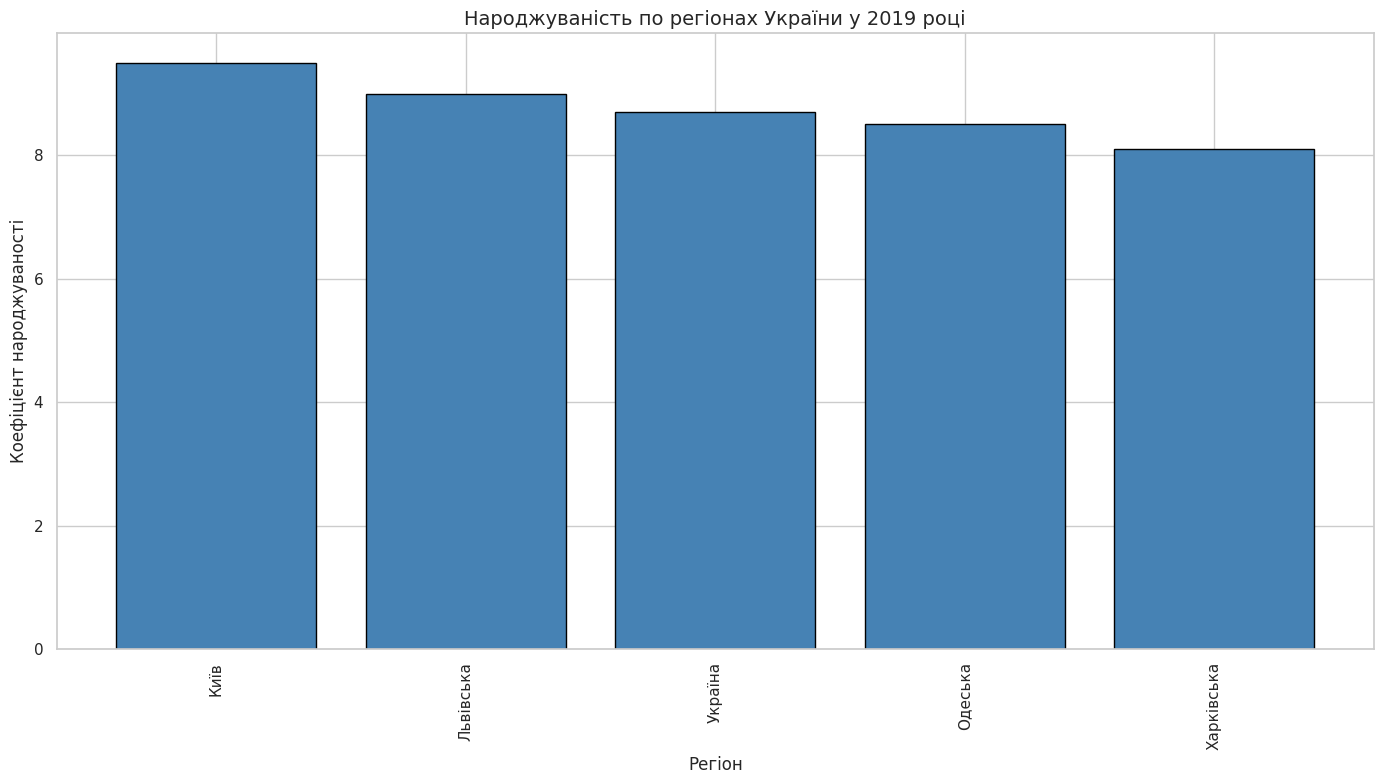

In [129]:
# 1. Стовпчикова діаграма народжуваності по регіонах у 2019 році
plot_df = birth_df[['Регіон', '2019']].sort_values('2019', ascending=False)

plt.figure(figsize=(14, 8))
plt.bar(plot_df['Регіон'], plot_df['2019'], color='steelblue', edgecolor='black')
plt.xticks(rotation=90)
plt.title('Народжуваність по регіонах України у 2019 році', fontsize=14)
plt.xlabel('Регіон')
plt.ylabel('Коефіцієнт народжуваності')
plt.tight_layout()
plt.show()

## Візуалізація

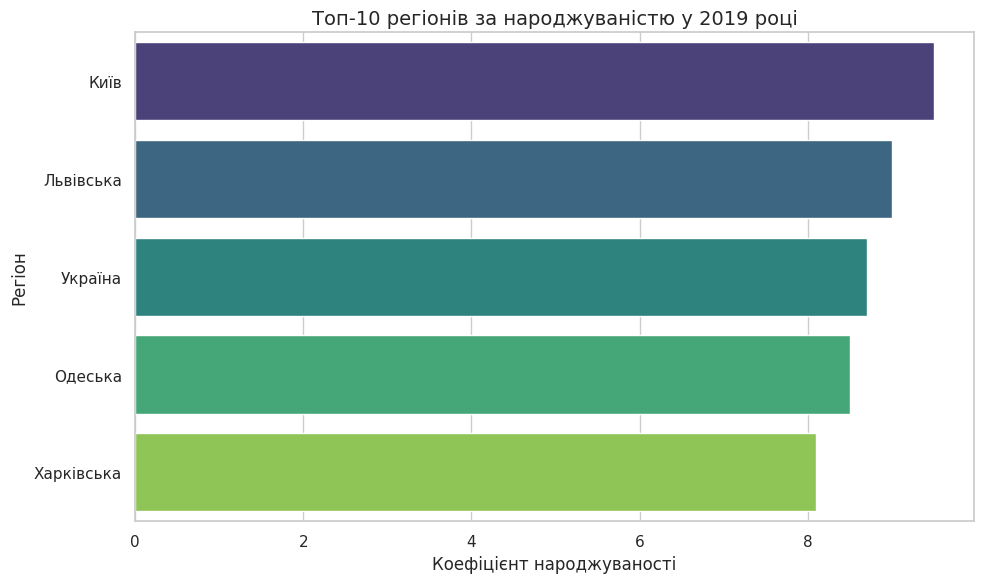

In [130]:
# 2. Горизонтальна діаграма: топ-10 регіонів за народжуваністю у 2019 році
top10_2019 = birth_df[['Регіон', '2019']].sort_values('2019', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_2019, x='2019', y='Регіон', hue='Регіон', dodge=False, palette='viridis', legend=False)
plt.title('Топ-10 регіонів за народжуваністю у 2019 році', fontsize=14)
plt.xlabel('Коефіцієнт народжуваності')
plt.ylabel('Регіон')
plt.tight_layout()
plt.show()

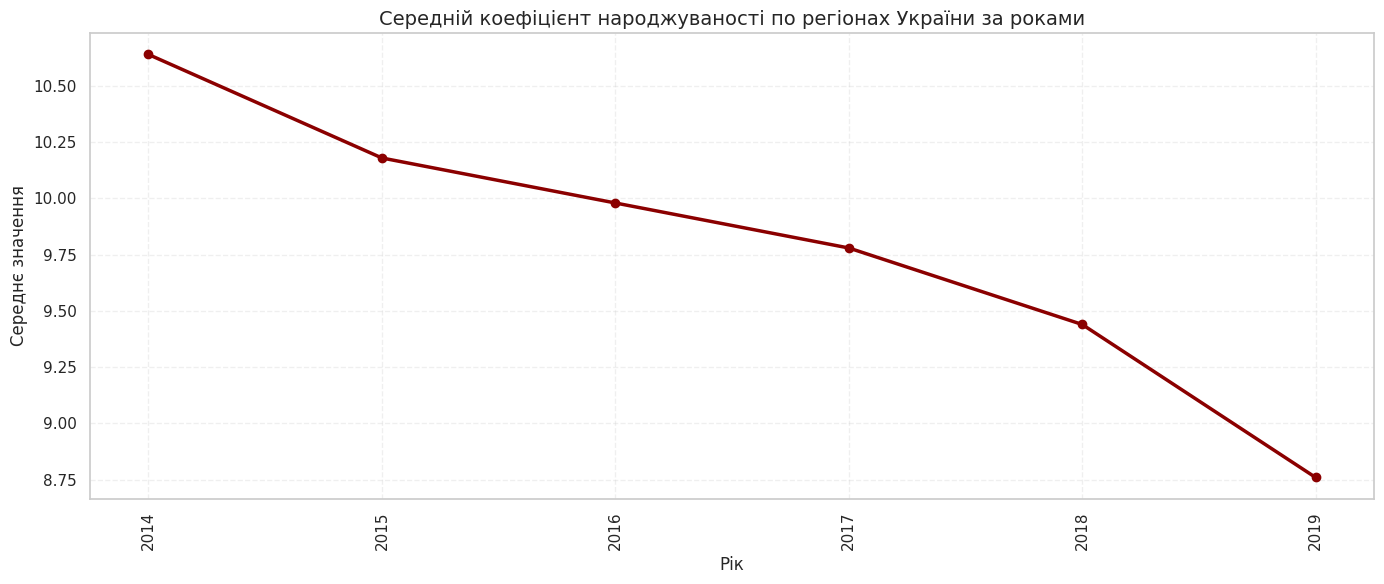

In [131]:
# 3. Лінійний графік: середній коефіцієнт народжуваності по роках
year_cols = [col for col in birth_df.columns if col != 'Регіон']
mean_by_year = birth_df[year_cols].mean().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(mean_by_year.index, mean_by_year.values, marker='o', linewidth=2.5, color='darkred')
plt.xticks(rotation=90)
plt.title('Середній коефіцієнт народжуваності по регіонах України за роками', fontsize=14)
plt.xlabel('Рік')
plt.ylabel('Середнє значення')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

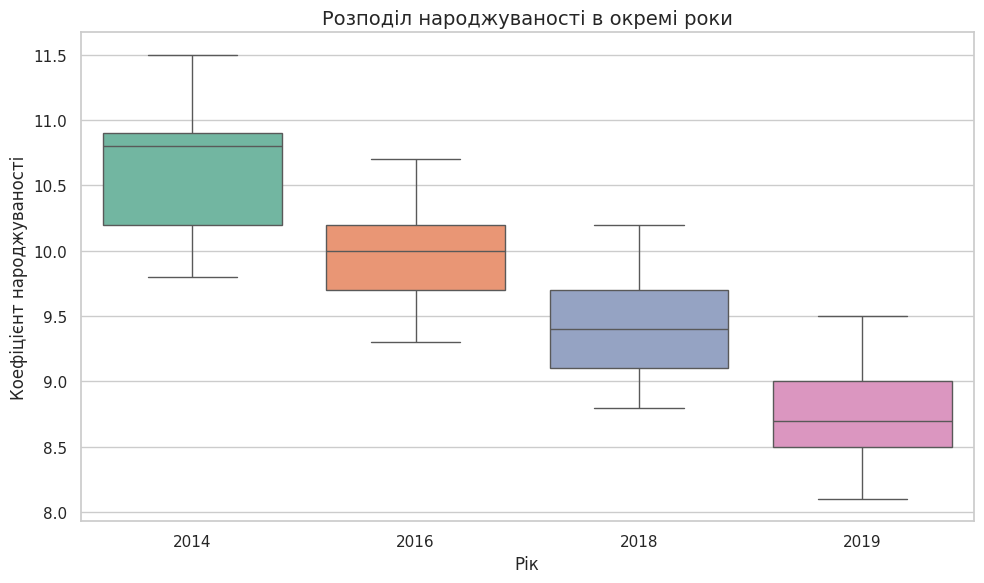

In [132]:
# 4. Boxplot: розподіл народжуваності для окремих років

selected_years = ['2014', '2016', '2018', '2019']

boxplot_df = birth_df[selected_years].melt(
    var_name='Рік',
    value_name='Коефіцієнт народжуваності'
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=boxplot_df,
    x='Рік',
    y='Коефіцієнт народжуваності',
    hue='Рік',
    legend=False,
    palette='Set2'
)

plt.title('Розподіл народжуваності в окремі роки', fontsize=14)
plt.xlabel('Рік')
plt.ylabel('Коефіцієнт народжуваності')
plt.tight_layout()
plt.show()

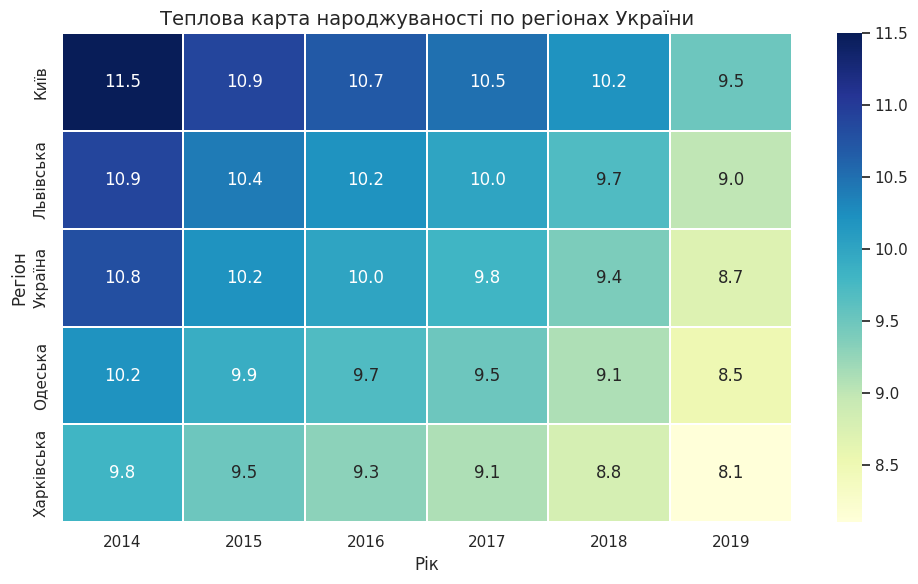

In [133]:
# 5. Теплова карта: народжуваність за доступні роки
heatmap_years = [col for col in birth_df.columns if col != 'Регіон']
heatmap_df = birth_df.set_index('Регіон')[heatmap_years].sort_values('2019', ascending=False)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, cmap='YlGnBu', linewidths=0.3, annot=True, fmt='.1f')
plt.title('Теплова карта народжуваності по регіонах України', fontsize=14)
plt.xlabel('Рік')
plt.ylabel('Регіон')
plt.tight_layout()
plt.show()


## Короткий висновок

- Дані зчитано з локального CSV-файлу `birth_rate_ukraine_1950_2019.csv`.
- За допомогою `head()` переглянуто перші рядки таблиці.
- Визначено розмір таблиці, типи стовпців та частку пропусків.
- Після видалення рядка `Україна` пропуски заповнено середніми значеннями відповідних стовпців.
- Отримано список регіонів, де народжуваність у 2019 році була вищою за показник по Україні.
- Знайдено регіон-лідер за 2014 рік і побудовано кілька різних візуалізацій.
